<a href="https://colab.research.google.com/github/Calebmi17/Disney-Logistical-analysis/blob/main/Disney_Logistics_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

#1. Create a date range for a busy summer month (recording every 15 mins)
dates = pd.date_range(start='2025-07-01 09:00:00', end='2025-07-31 22:00:00', freq='15min')
#2. Filter out times when the park is closed (keep between the hours of 9AM and 10PM)
dates = dates[(dates.hour >= 9) & (dates.hour <= 21)]

#3. Generate the synthetic wait times (creating a bell curve that peaks around 2PM)
hours = dates.hour
base_wait = 45
#Quadratic curve peaking at hour 14 (2PM)
peak_impact = -15 * ((hours - 14) ** 2) + 60
peak_impact = np.where(peak_impact < 0, 0, peak_impact)

# Add random crowd noise and round to the nearest 5 minutes
posted_waits = base_wait + peak_impact + np.random.normal(0, 10, len(dates))
posted_waits = np.round(posted_waits / 5) * 5

# SIMULATE ANOMALIES: 2% chance the ride breaks down (logged as -999)
posted_waits = np.where(np.random.rand(len(dates)) < 0.02, -999, posted_waits)

#4. Build the DataFrame
df = pd.DataFrame({
    'datetime': dates,
    'SPOSTMIN': posted_waits, #Posted Wait
    'SACTMIN': posted_waits * 0.8 + np.random.normal(0, 5, len(dates)) #Actual Wait
})

# If the ride is broken down, the actual wait time is not a number(NaN)
df['SACTMIN'] = np.where(df['SPOSTMIN'] == -999, np.nan, df['SACTMIN'])

print("---- Seven Dwarves Mine Train (Simulated Data) ---")
display(df.head(10))

---- Seven Dwarves Mine Train (Simulated Data) ---


,datetime,SPOSTMIN,SACTMIN
0,2025-07-01 09:00:00,40.0,29.986460
1,2025-07-01 09:15:00,55.0,35.857978
2,2025-07-01 09:30:00,50.0,36.145434
3,2025-07-01 09:45:00,55.0,50.385913
4,2025-07-01 10:00:00,40.0,25.076020
5,2025-07-01 10:15:00,60.0,50.248932
6,2025-07-01 10:30:00,55.0,41.671595
7,2025-07-01 10:45:00,55.0,44.853821
8,2025-07-01 11:00:00,55.0,36.368520
9,2025-07-01 11:15:00,50.0,30.599113


In [ ]:
import numpy as np

#1 Flagging Operational Down Time
# Create a boolean (T/F)column where true means the ride is broken down
df['is_down'] = df['SPOSTMIN'] == -999

# Cleaning the Anomalies
# If we leave -999 in the column it will incorrectly skew our average wait time
# replace -999 with NaN so that it doesn't effect our averages
df['SPOSTMIN'] = df['SPOSTMIN'].replace(-999, np.nan)

# Feature engineering(Adding Context)
df['hour'] = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.day_name() # Outputs day of the week name
df['is_weekend'] = df['datetime'].dt.dayofweek >= 5

# Verify Changes
print("--- Snapshot of Ride Breakdowns ---")
# Log of Ride Breakdowns
display(df[df['is_down'] == True].head())

print("\n--- Cleaned Data Statistics ---")
display(df.describe())

--- Snapshot of Ride Breakdowns ---


,datetime,SPOSTMIN,SACTMIN,is_down,hour,day_of_week,is_weekend
32,2025-07-01 17:00:00,NaN,NaN,True,17,Tuesday,False
44,2025-07-01 20:00:00,NaN,NaN,True,20,Tuesday,False
57,2025-07-02 10:15:00,NaN,NaN,True,10,Wednesday,False
155,2025-07-03 21:45:00,NaN,NaN,True,21,Thursday,False
205,2025-07-04 21:15:00,NaN,NaN,True,21,Friday,False



--- Cleaned Data Statistics ---


,datetime,SPOSTMIN,SACTMIN,hour
count,1612,1578.000000,1578.000000,1612.000000
mean,2025-07-16 15:22:30,56.929658,45.693278,15.000000
min,2025-07-01 09:00:00,15.000000,9.067082,9.000000
25%,2025-07-08 18:41:15,40.000000,31.949318,12.000000
50%,2025-07-16 15:22:30,50.000000,39.975889,15.000000
75%,2025-07-24 12:03:45,65.000000,54.125450,18.000000
max,2025-07-31 21:45:00,135.000000,107.168988,21.000000
std,NaN,23.730269,19.566406,3.742818


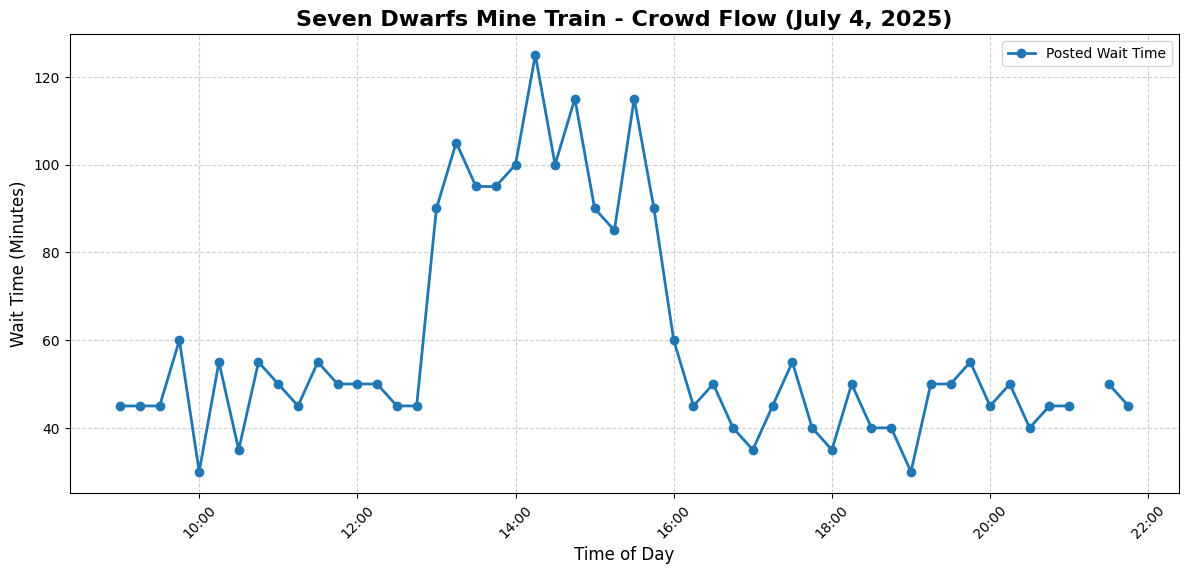

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

#  Filter the Data
# Take a single day from the data. July 4th
target_date = pd.to_datetime('2025-07-04').date()
single_day = df[df['datetime'].dt.date == target_date].copy()

# Canvas Setup
plt.figure(figsize=(12,6))

# Plot the Line
# We plot datetime on X, and the cleaned SPOSTMIN on Y
# marker adds a dot for every 15 minute observation
plt.plot(single_day['datetime'], single_day['SPOSTMIN'], marker = 'o', linestyle = '-', color = '#1f77b4', linewidth = 2, label = 'Posted Wait Time')

# Titles and Labels
plt.title('Seven Dwarfs Mine Train - Crowd Flow (July 4, 2025)', fontsize = 16, fontweight = 'bold')
plt.xlabel('Time of Day', fontsize = 12)
plt.ylabel('Wait Time (Minutes)', fontsize = 12)

# Format for proffesionalism
plt.grid(True, linestyle = '--', alpha = 0.6)
plt.xticks(rotation = 45)
plt.tight_layout()

# X-axis Time Formatting
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# Show legend and render the plot
plt.legend()
plt.savefig('crowd_flow_chart.png', bbox_inches='tight')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

print("--- Training the Predictive Model ---")

# Prepare the Data
#We cannot train the model on times the ride was broken (NaN values)
model_df = df.dropna(subset=["SPOSTMIN"]).copy()

#Convert 'is_weekend' true/false into 1s and 0s so the math works
model_df['is_weekend_num'] = model_df['is_weekend'].astype(int)

#Define our features (X) - what is used to predict
X = model_df[['hour', 'is_weekend_num']]

#Define our target (y) what we are trying to predict
y = model_df['SPOSTMIN']

# Split the Data
#The model is given 80% of the data to study and the remaining 20% is use to test the model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the Model
print("Training Random Forest algorithm..")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluate the Model
# Test the model on the 20% data that is witheld
predictions = rf_model.predict(X_test)

# Mean absolute error calculation
mae = mean_absolute_error(y_test, predictions)
print(f"\nModel Accuracy:")
print(f"Mean Absolut Error (MAE): {mae:.2f} minutes")

# Future prediction for saturday at 2pm
future_scenario = [[14, 1]]
predicted_wait = rf_model.predict(future_scenario)[0]
print(f"\nPredicted wait time for Saturday at 2:00 PM: {predicted_wait:.0f} minutes")

--- Training the Predictive Model ---
Training Random Forest algorithm..

Model Accuracy:
Mean Absolut Error (MAE): 8.25 minutes

Predicted wait time for Saturday at 2:00 PM: 105 minutes


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
